# Set Up

In [76]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt 
from matplotlib.ticker import ScalarFormatter # per i ticks
import seaborn as sns
import scipy.stats 
import pickle

# Impostare il seed dell'esperimento così da renderlo riproducibile
#np.random.seed(seed=4)

# region Importazione JSON di configurazione
import json
import sys
path_config =   r"/Users/mattia/Desktop/Università/Data Science in Python"
# Importazione file di configurazione classico
with open(f'{path_config}/config.json', 'r') as file:
    config = json.load(file)
sys.path.append(config["path_python_pacchetti"]) # aggiunta pacchetti classici
# endregion

path_risultati = r"/Users/mattia/Desktop/Università/Data Science in Python/_Progetti/Solitari/Solitario123"

from formattazione_testo import formatta_percentuali,formatta_numeri
from LaTeX import LaTeX

from funzioni_solitario123 import __simulazione_solitario123_vettorializzata__,__simulazione_solitario123__
from statistica_descrittiva import tabella_frequenza_univariata,percentili

In [77]:
# Inizializzare la classe per il report .tex poi pdf
doc = LaTeX(formato="V",
            titolo_report="Tasso di successo del solitario 123",
            indice=False,
            separazione_header_contenuto=False,
            separazione_title_indice=False,
            autore="Mattia",
            data="\\today",
            geometry='left= 3.81cm,right=2.54cm,top=2.54cm,bottom=3.81cm',
            numerazione_pagine = "fancy",
            linguaggio='italiano',
            toc_depth= 3
)

# Descrizione del solitario

Il solitario chiamato 1, 2 ... 3 si gioca con un mazzo di carte italiane (40 carte divise in 4 semi, ogni seme va da 1 al 10).   
Dopo aver mescolato le carte si prende la prima carta del mazzo, se questa è un asso (1) si perde la partita,
se non lo è si va alla seconda. Se questa è un 2 si perde la partita, altrimenti si va alla terza. Se la terza è un 3 si perde, altrimenti si va alla carta successiva e si rinizia il conteggio se è 1 perso....

In questo script si simula il gioco del solitario X volte per cercare di stimare tramite bootstrap le probabilità di successo non riuscendo a calcolarle tramite la probabilità classica data la natura complessa del solitario. 

In [78]:
doc.text("""Il solitario chiamato 1, 2 ... 3 si gioca con un mazzo di carte italiane (40 carte divise in 4 semi, ogni seme va da 1 al 10).   
Dopo aver mescolato le carte si prende la prima carta del mazzo, se questa è un asso (1) si perde la partita,
se non lo è si va alla seconda. Se questa è un 2 si perde la partita, altrimenti si va alla terza. Se la terza è un 3 si perde, altrimenti si va alla carta successiva e si rinizia il conteggio se è 1 perso....""")

# Prima analisi

## Effettuo il "bootstrap"

Effettuo diverse simulazioni con un numero di prove diverse per capire se il tasso di successo converge.

In [79]:
# Numero di prove per ogni simulazione.
simulazioni = [100,
               1000,
               10000,
               100000,
               1000000,
               10000000
              ]

# Inizializzo il dizionario che conterrà i risultati delle simulazioi
risultati_simulazioni_n_vittorie = {}
risultati_simulazioni_tasso_successo = {}

doc.section("Simulazioni") # aggiungo una sezione 

# Iterare per effettuare le simulazioni
for numero_prove in simulazioni:
   
   # Inizializzo il numero di vittore per simulazione
   vittorie = 0

   # aggiungo al file .tex una sottosezione per la simulazion i-esima
   doc.subsection(f"Simulazione con {formatta_numeri(numero_prove)} prove")
   
   # Per l' i-esima simulazione effettuo le N prove specificate
   vittorie = __simulazione_solitario123_vettorializzata__(n_prove=numero_prove)

   # Calcolo il tasso di successo
   tasso_di_successo = (vittorie/numero_prove)*100
   
   # Creo un output testuale descrivente i risultati per la i-esima simulazione con le N prove specificate
   risultato_testuale = f"Su {formatta_numeri(numero_prove)} prove il solitario è stato vinto {formatta_numeri(vittorie)} volte.\nTasso di successo {formatta_percentuali(tasso_di_successo,formattazione_italiana=True,decimali=2,percentuale=False)}\%\n"

   doc.text(risultato_testuale) # Aggiungo l'output testuale al file .tex
   print(risultato_testuale.replace("\\","")) 
   
   # Assegno i risultati della simulazione 
   risultati_simulazioni_n_vittorie[numero_prove] = vittorie
   
   risultati_simulazioni_tasso_successo[numero_prove] = tasso_di_successo
   

Su 100 prove il solitario è stato vinto 0 volte.
Tasso di successo 0,00%

Su 1.000 prove il solitario è stato vinto 11 volte.
Tasso di successo 1,10%

Su 10.000 prove il solitario è stato vinto 107 volte.
Tasso di successo 1,07%

Su 100.000 prove il solitario è stato vinto 854 volte.
Tasso di successo 0,85%

Su 1.000.000 prove il solitario è stato vinto 8.346 volte.
Tasso di successo 0,83%

Su 10.000.000 prove il solitario è stato vinto 83.319 volte.
Tasso di successo 0,83%



## Grafico iterazioni-successo

In [80]:
doc.newpage()
doc.section("Grafici iterazioni successi")

### Dati su 10000 simulazioni da 90000 a 100000 ripetizioni

Importare i dati simulati in separata instanza.

In [81]:
with open(f"{path_risultati}/Risultati/risultati_simulazioni_tasso_successo.pkl", "rb") as f:
   risultati_simulazioni_tasso_successo = pickle.load(f)
    
with open(f"{path_risultati}/Risultati/risultati_simulazioni_tasso_successo.pkl", "rb") as f:
   risultati_simulazioni_n_vittorie = pickle.load(f)

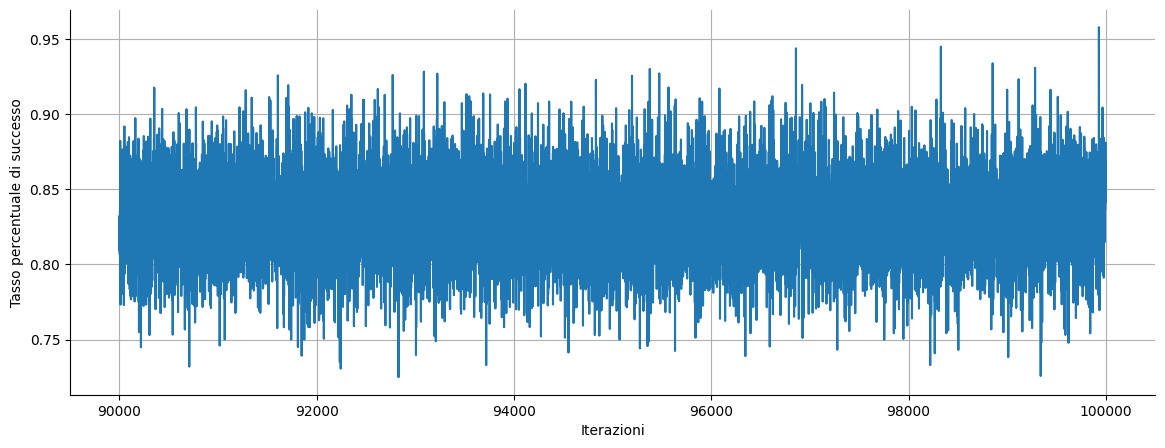

In [82]:
x = list(risultati_simulazioni_tasso_successo.keys())
y = list(risultati_simulazioni_tasso_successo.values())

fig = plt.figure()               
plt.gcf().set_size_inches((14, 5)) 
plt.plot(x,y)
# Set plot labels and title
plt.xlabel('Iterazioni', fontsize=10)
plt.ylabel('Tasso percentuale di successo', fontsize=10)
#plt.title('Tasso di successo del solitario 123', fontsize=15)

ax = plt.gca()
formatter = ScalarFormatter(useOffset=False)
formatter.set_scientific(False)
ax.xaxis.set_major_formatter(formatter)
sns.despine()
plt.grid()
path_figura = f"{path_risultati}/Immagini/Grafico_iterazioni-tassoSuccesso.png"
fig.savefig(path_figura, bbox_inches="tight",dpi=300) # Salvare una figura+
doc.image(path=path_figura,
          scale=0.51,
          title = "Tasso di successo per ogni iterazione",
          titolo_alto =True,
          numerare_figura = True,
          centering=True,
          offset = 0
          )

plt.show()

### 10000 iterazioni da 100 ripetizioni

In [83]:
# Iterare per effettuare le simulazioni
risultati_simulazioni_n_vittorie = {}
risultati_simulazioni_tasso_successo = {}
iterazioni = 100
for numero_prove in tqdm(range(0,100)):
   
   
   vittorie = __simulazione_solitario123_vettorializzata__(n_prove = 100) # restituisce 1 se ha successo 0 se non lo ha. Basta quindi sommare per tenere traccia dei successi

   # Calcolo il tasso di successo
   tasso_di_successo = (vittorie/numero_prove)*100
   
   # Assegno i risultati della simulazione 
   risultati_simulazioni_n_vittorie[numero_prove] = vittorie
   
   risultati_simulazioni_tasso_successo[numero_prove] = tasso_di_successo



  0%|          | 0/100 [00:00<?, ?it/s]/var/folders/j4/9fk3st2d30g22vff83pj6cnw0000gn/T/ipykernel_6134/2664201543.py:11: RuntimeWarning: invalid value encountered in scalar divide
  tasso_di_successo = (vittorie/numero_prove)*100
100%|██████████| 100/100 [00:00<00:00, 6966.59it/s]


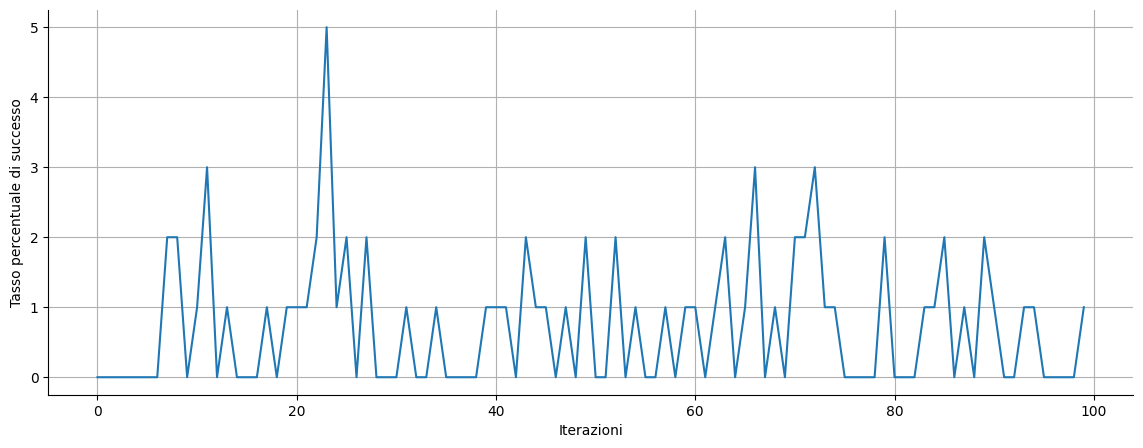

In [84]:
x = list(risultati_simulazioni_n_vittorie.keys())
y = list(risultati_simulazioni_n_vittorie.values())

fig = plt.figure()               
plt.gcf().set_size_inches((14, 5)) 
plt.plot(x,y)
# Set plot labels and title
plt.xlabel('Iterazioni', fontsize=10)
plt.yticks([i for i in range(0,max(risultati_simulazioni_n_vittorie.values())+1)])
plt.ylabel('Tasso percentuale di successo', fontsize=10)
#plt.title('Tasso di successo del solitario 123', fontsize=15)

ax = plt.gca()
formatter = ScalarFormatter(useOffset=False)
formatter.set_scientific(False)
ax.xaxis.set_major_formatter(formatter)
sns.despine()
plt.grid()
path_figura = f"{path_risultati}/Immagini/Grafico_iterazioni-tassoSuccessoRipetizionidi100.png"
fig.savefig(path_figura, bbox_inches="tight",dpi=300) # Salvare una figura+
doc.image(path=path_figura,
          scale=0.51,
          title = "Tasso di successo per ogni iterazione",
          titolo_alto =True,
          numerare_figura = True,
          centering=True,
          offset = 0
          )

plt.show()

In [85]:
df = pd.DataFrame(y,columns=["Successi"])
freq = tabella_frequenza_univariata(data=df,variabile="Successi",
                                    verbose=True,
                                    add_margin=True,
                                    order = [i for i in range(0,max(y)+1)],
                                    formattazione_italiana = True,
                                    percentuali=True)
doc.table(dataframe=freq,include_index=False)

ValueError: La variabile '4' specificata nella lista di ordinamento non è presente nel dataframe.

# Primo successo

Osservare  1000 volte dopo quante prove avviene il primo successo.

In [ ]:
doc.newpage()
doc.section("Primo successo dopo quante iterazioni (1000 prove)")

## Simulazione

In [ ]:
successi_dopo_quante_iterazioni = {}

for i in tqdm(range(0,1000)):

   prove = 0
   while True:
      prove += 1 
      if __simulazione_solitario123__() ==1:
         successi_dopo_quante_iterazioni[i] = prove
         break 
      
# Inserisco i risultati in un dataframe pandas per poterci lavorare meglio
frequenze = pd.DataFrame(successi_dopo_quante_iterazioni.values(),columns=["Successi"])
frequenze.reset_index(inplace=True)

100%|██████████| 1000/1000 [00:00<00:00, 1417.64it/s]


## Statistiche descrittive dei successi

In [ ]:
statistiche_descrittive_successi = pd.DataFrame(frequenze["Successi"].describe()).T
statistiche_descrittive_successi.index = [""]
display(statistiche_descrittive_successi)

# Percentili
quantili_parte1 = percentili(x = frequenze["Successi"],start = 0,stop = 0.5,step = 0.05)
quantili_parte2 = percentili(x = frequenze["Successi"],start = 0.5,stop = 1.05,step = 0.05)
display(quantili_parte1)
display(quantili_parte2)

,count,mean,std,min,25%,50%,75%,max
,1000.0,118.932,121.960337,1.0,32.0,82.0,165.25,1198.0


,0.00,0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45
,1.0,7.0,12.0,19.0,25.0,32.0,40.0,49.0,59.6,68.0


,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95,1.00
,82.0,92.45,110.0,126.0,145.0,165.25,195.0,224.15,278.1,359.1,1198.0


In [ ]:
doc.table(statistiche_descrittive_successi,title="Statistiche descrittive 'tentativo al primo successo'")
doc.table(quantili_parte1,title="Percentili")
doc.table(quantili_parte2,title="Percentili")

## Funzione di ripartizione empirica

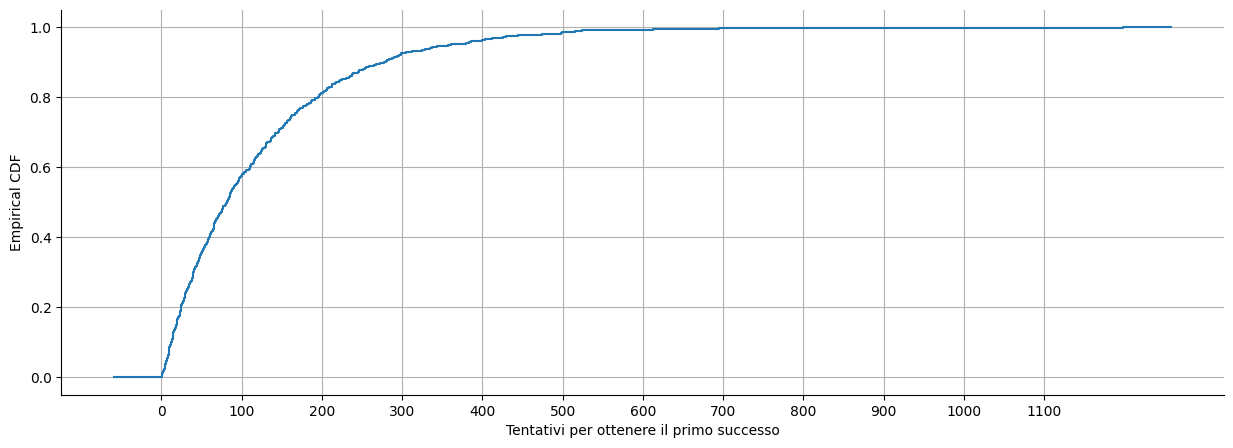

In [ ]:
res = scipy.stats.ecdf(frequenze['Successi']) # calcolare la ecdf tramite scipy

# Plottare la ecdf
fig = plt.figure(figsize=(15, 5)) 
ax = plt.subplot()
res.cdf.plot(ax)
plt.xlabel('Tentativi per ottenere il primo successo')
plt.ylabel('Empirical CDF')

sns.despine()
plt.grid()
plt.xticks([i for i in range(0,max(frequenze['Successi']),100)])
path_figura = f"{path_risultati}/Immagini/ECDF_PrimoSuccesso.png"
fig.savefig(path_figura, bbox_inches="tight",dpi=300) # Salvare una figura
doc.image(path=path_figura,
          scale=0.51,
          title = "Funzione di ripartizione empirica - numero di tentativi per il primo successo",
          titolo_alto =True,
          numerare_figura = True,
          centering=True,
          offset = 0
          )

plt.show()

## Istogramma primo successo 

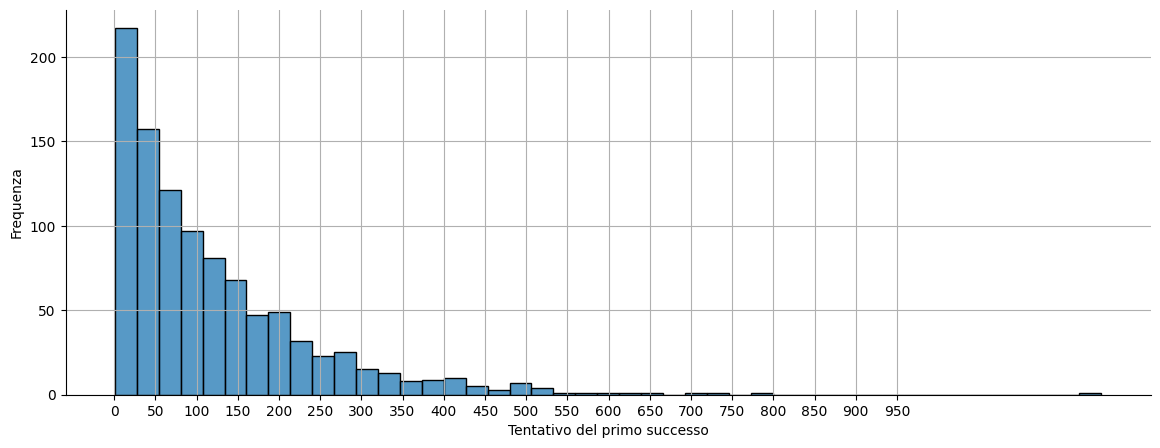

In [ ]:
fig = plt.figure()               
plt.gcf().set_size_inches((14, 5)) 
sns.histplot(data = frequenze,          # Dataframe 
             x = "Successi"
            )
plt.xlabel('Tentativo del primo successo', fontsize=10)
plt.xticks([i for i in range(0,1000,50)])
plt.ylabel('Frequenza', fontsize=10)
sns.despine()
plt.grid()
path_figura = f"{path_risultati}/Immagini/IstogrammaPrimoSuccesso.png"
fig.savefig(path_figura, bbox_inches="tight",dpi=300) # Salvare una figura
doc.image(path=path_figura,
          scale=0.51,
          title = "Tasso di successo per ogni iterazione",
          titolo_alto =True,
          numerare_figura = True,
          centering=True,
          offset = 0
          )

plt.show()

In [ ]:
# crea i bins da 1 a 1000 con step 25
bins = np.arange(0, max(frequenze['Successi']), 25)

# applica il binning
frequenze['bin'] = pd.cut(frequenze['Successi'], bins=bins)
frequenze_bins = tabella_frequenza_univariata(data=frequenze,variabile="bin",percentuali=True)
doc.table(dataframe=frequenze_bins,title="Primo successo bins")

# Esportazioni risultati

In [ ]:
doc.export(path=f"{path_risultati}/RisultatiSimulazioniSolitario123.tex",
            knit=True,
            overwrite=True
            )